# This notebook contains a full and extensive research on Alphabet inc

# SECTION A: IMPORTING THE LIBRARIES AND DEFINING VARIABLES LIKE DATE AND ASSETS

In [84]:
import numpy as np

In [85]:
import pandas as pd

In [86]:
import yfinance as yf

In [87]:
import matplotlib.pyplot as plt
COLORS = {
    "Alphabet": "#1a73e8", 
    "S&P500":   "#5f6368",   
    "Amazon":   "#ff9900",
    "Meta":     "#34a853",
}

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 150,            
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

In [88]:
START_DATE = '2019-01-01'
END_DATE = '2026-01-01'
TECH_DATE = '2021-01-01'
CURRENT_DATE = '2026-01-01'

In [89]:
ALPHABET = 'GOOGL'
MARKET = '^GSPC'
PEERS = ['META', 'NFLX', 'AMZN']
ASSETS = [ALPHABET, MARKET] + PEERS

# GOOGL contains the historical data of Alphabet from 2019 till 2025 ending 
# ALL contains the historical data of all the assets included in analysis from 2019 till 2025 ending 
# ALL2026 contains the data of all the assets for the year 2026

In [90]:
GOOGL = yf.download(ALPHABET, START_DATE, END_DATE, auto_adjust = 'false')['Close']

[*********************100%***********************]  1 of 1 completed


In [91]:
Tickers = ASSETS
ALL = pd.DataFrame()
for t in Tickers:
    ALL[t] = yf.download (t, START_DATE, END_DATE, auto_adjust ='false')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [92]:
Tickers = ASSETS
ALL2026 = pd.DataFrame()
for t in Tickers:
    ALL2026[t] = yf.download(t, CURRENT_DATE, auto_adjust = 'false')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# PRICE AND MARKET PERFORMANCE (ALPHABET AND ALL BENCH MARKS)

In [93]:
DSR = ALL.pct_change()

In [94]:
DLR = np.log(ALL).diff(1)

In [95]:
Monthly_Returns = (1+DSR).resample('ME').prod()-1

In [96]:
Annual_Returns = (1+DSR).resample('YE').prod()-1

In [97]:
Cumulative_Returns = (1+DSR).cumprod()-1

In [98]:
ANN_RETURNS = DSR.mean()*252

In [99]:
AVG_RETURNS = DSR.mean()

In [105]:
ANN_RETURNS

GOOGL    0.305510
^GSPC    0.163715
META     0.316296
NFLX     0.273148
AMZN     0.215661
dtype: float64

In [106]:
Annual_Returns

,GOOGL,^GSPC,META,NFLX,AMZN
Date,,,,,
2019-12-31,0.269949,0.287148,0.512751,0.208884,0.200574
2020-12-31,0.308536,0.162589,0.330865,0.671138,0.762561
2021-12-31,0.652958,0.268927,0.231329,0.114123,0.023768
2022-12-31,-0.390896,-0.194428,-0.642218,-0.510524,-0.496152
2023-12-31,0.583248,0.242305,1.941333,0.651112,0.808810
2024-12-31,0.360056,0.233090,0.660489,0.830677,0.443925
2025-12-31,0.659936,0.163878,0.130931,0.051923,0.052099


# Historical Charts: 2019 - 2025 

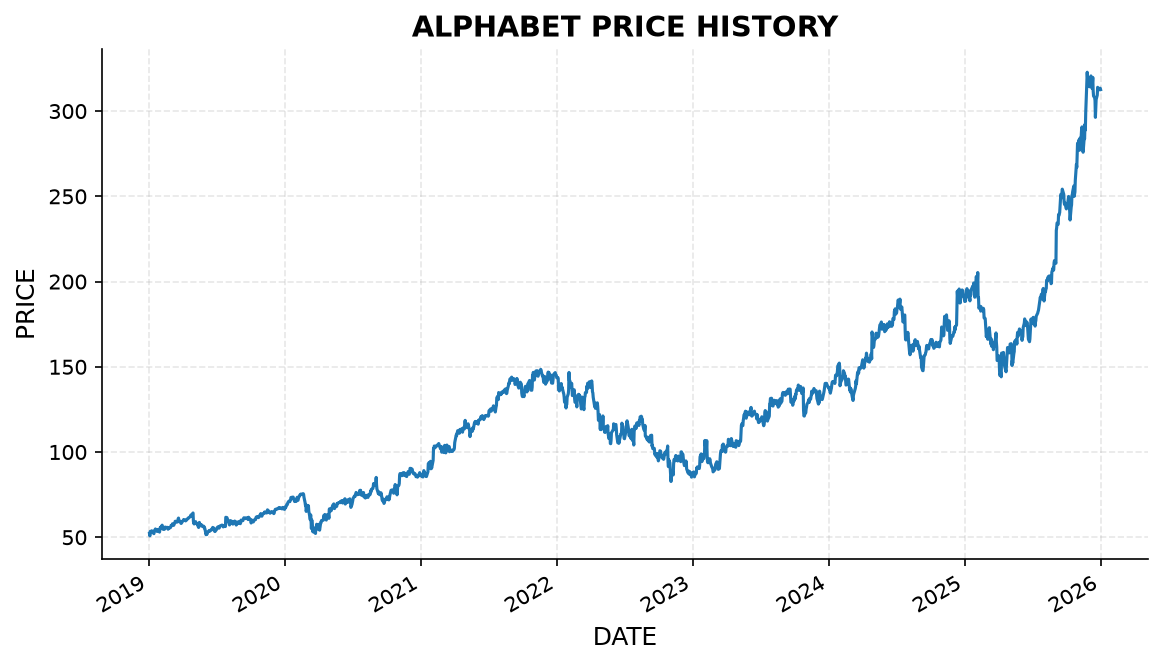

In [108]:
ALL['GOOGL'].plot()
plt.title('ALPHABET PRICE HISTORY')
plt.xlabel('DATE')
plt.ylabel('PRICE')
plt.show()

In [109]:
Normalized = ALL[['GOOGL','^GSPC']]/ALL[['GOOGL','^GSPC']].iloc[0] * 100

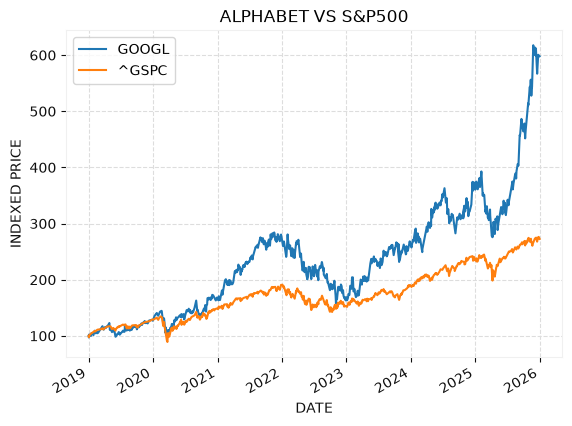

In [217]:
Normalized.plot()
plt.title ('ALPHABET VS S&P500')
plt.xlabel ('DATE')
plt.ylabel ('INDEXED PRICE')
plt.show()

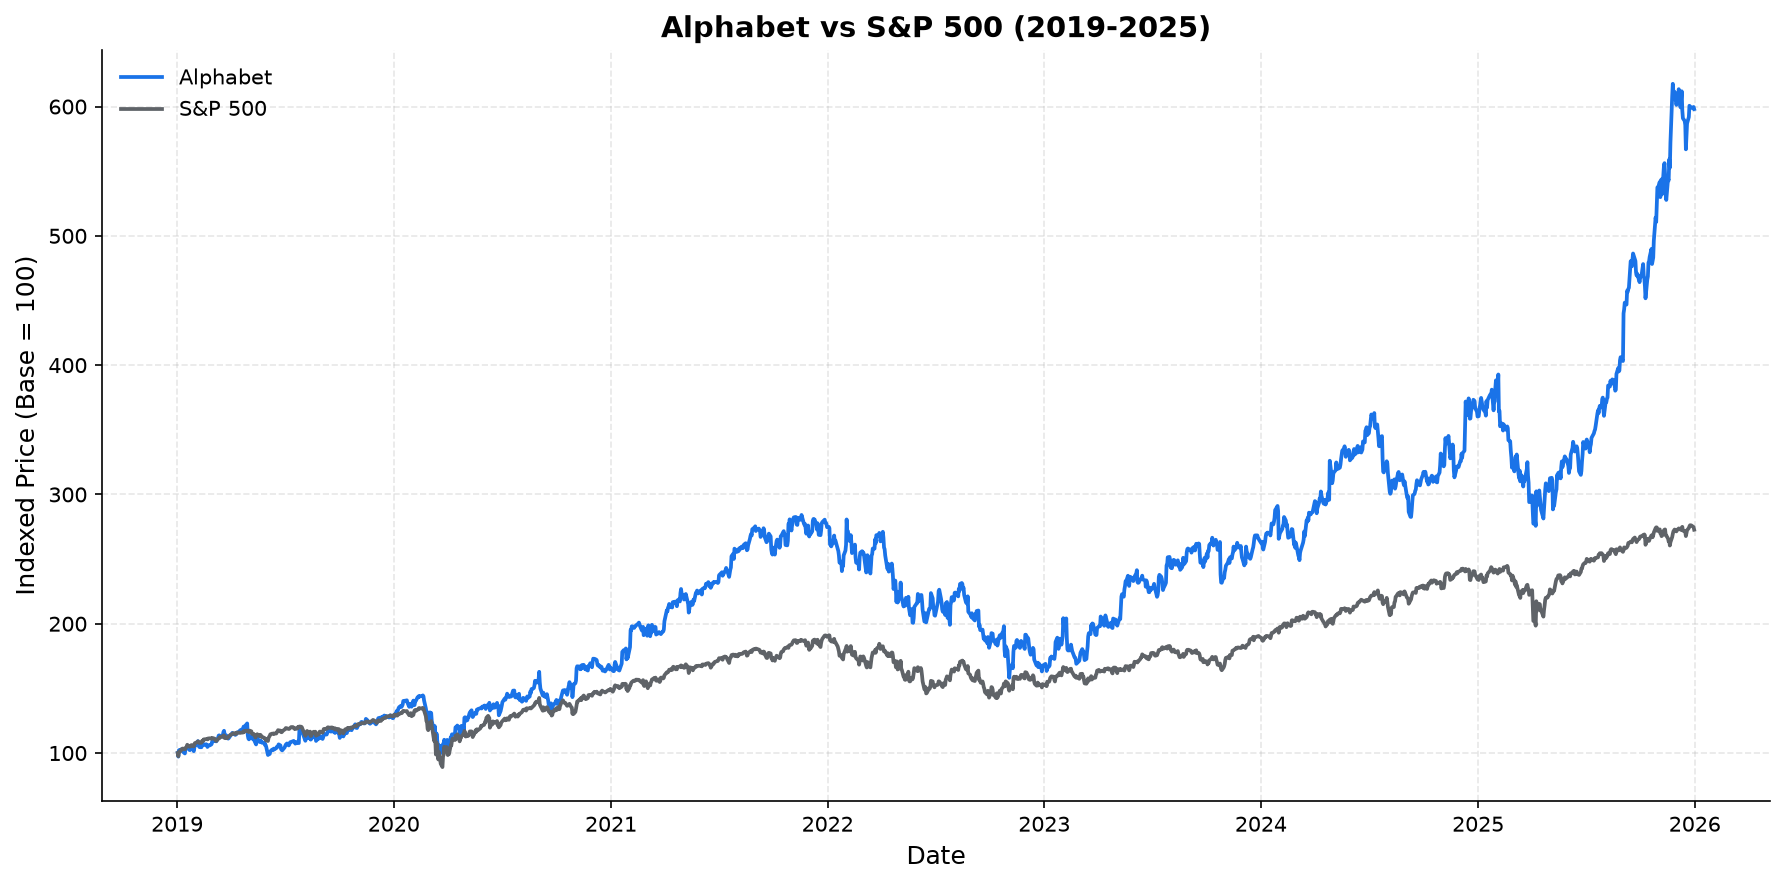

In [113]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(Normalized.index, Normalized['GOOGL'],
        label="Alphabet",
        color=COLORS["Alphabet"],
        linewidth=1.8)

ax.plot(Normalized.index, Normalized['^GSPC'],
        label="S&P 500",
        color=COLORS["S&P500"],
        linewidth=1.8)

ax.set_title("Alphabet vs S&P 500 (2019-2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Price (Base = 100)")
ax.legend()

fig.tight_layout()
fig.savefig("alphabet_vs_sp500.png")

plt.show()

In [114]:
fig.savefig("alphabet_vs_sp500.png", dpi=300, bbox_inches="tight")

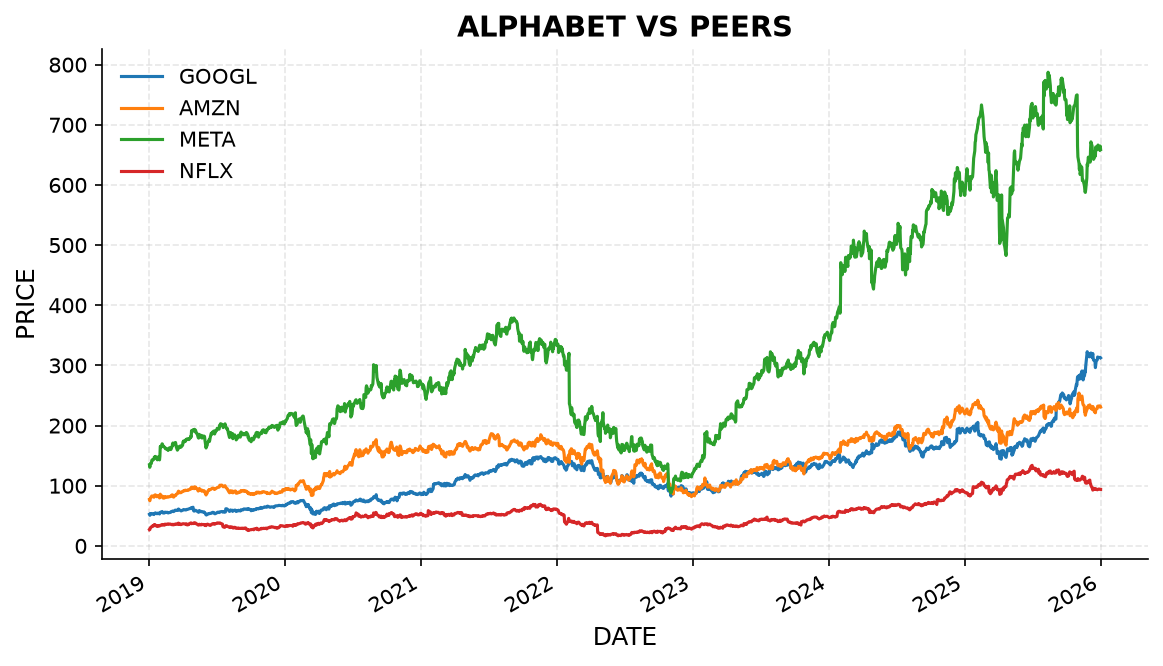

In [116]:
ALL[['GOOGL', 'AMZN', 'META','NFLX']].plot()
plt.title('ALPHABET VS PEERS')
plt.xlabel('DATE')
plt.ylabel('PRICE')
plt.show()

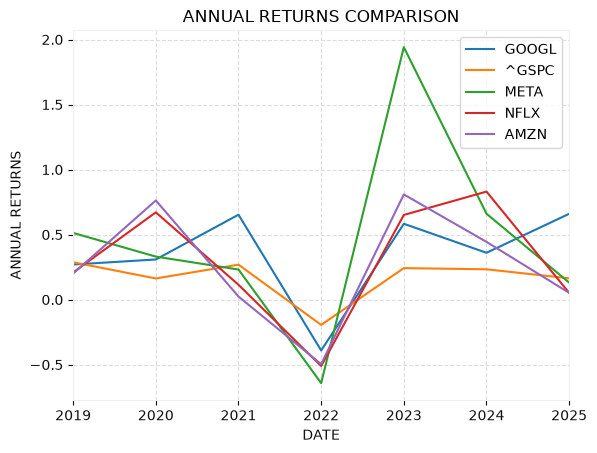

In [218]:
Annual_Returns.plot()
plt.title('ANNUAL RETURNS COMPARISON')
plt.xlabel('DATE')
plt.ylabel('ANNUAL RETURNS')
plt.show()

# RISK ANALYSIS 

In [118]:
ANN_VOL = DSR.std()*np.sqrt(252)

In [119]:
VARIANCE = DSR.var()*252

In [120]:
BEST_DAILY_RETURN = DSR.max()

In [121]:
WORST_DAILY_RETURN = DSR.min()

In [122]:
BEST_MONTHLY_RETURN = Monthly_Returns.max()

In [123]:
WORST_MONTHLY_RETURN = Monthly_Returns.min()

In [124]:
BEST_YEARLY_RETURN = Annual_Returns.max()

In [125]:
WORST_YEARLY_RETURN = Annual_Returns.min()

In [126]:
BEST_DATE = Annual_Returns.idxmin()

In [127]:
BEST_DATE

GOOGL   2022-12-31
^GSPC   2022-12-31
META    2022-12-31
NFLX    2022-12-31
AMZN    2022-12-31
dtype: datetime64[s]

In [128]:
ANN_VOL

GOOGL    0.313679
^GSPC    0.199381
META     0.418959
NFLX     0.426105
AMZN     0.341625
dtype: float64

In [129]:
RISK_SUMMARY = pd.DataFrame({'Annualized Volatility': ANN_VOL,
                             'Best Daily Return': BEST_DAILY_RETURN,
                             'Worst Daily Return': WORST_DAILY_RETURN,
                             'Best Monthly Return': BEST_MONTHLY_RETURN,
                             'Worst Montly Return': WORST_MONTHLY_RETURN, 
                             'Best Yearly Return' : BEST_YEARLY_RETURN, 
                             'Worst Yearly Return': WORST_YEARLY_RETURN})

In [130]:
RISK_SUMMARY

,Annualized Volatility,Best Daily Return,Worst Daily Return,Best Monthly Return,Worst Montly Return,Best Yearly Return,Worst Yearly Return
GOOGL,0.313679,0.102244,-0.116341,0.159000,-0.179467,0.659936,-0.390896
^GSPC,0.199381,0.095154,-0.119841,0.126844,-0.125119,0.287148,-0.194428
META,0.418959,0.232824,-0.263901,0.267711,-0.326342,1.941333,-0.642218
NFLX,0.426105,0.168543,-0.351166,0.286098,-0.491818,0.830677,-0.510524
AMZN,0.341625,0.135359,-0.140494,0.270596,-0.237525,0.808810,-0.496152


# DRAWDOWN ANALYSIS 

In [131]:
RUNNING_MAX = ALL.cummax()

In [132]:
DRAWDOWN = (ALL - RUNNING_MAX)/RUNNING_MAX

In [133]:
MAXIMUM_DRAWDOWN = DRAWDOWN.min()

In [134]:
MAXIMUM_DRAWDOWN

GOOGL   -0.443200
^GSPC   -0.339250
META    -0.767361
NFLX    -0.759473
AMZN    -0.561453
dtype: float64

In [135]:
MDD_DATE = DRAWDOWN['GOOGL'].idxmin()

In [136]:
MDD_DATE

Timestamp('2022-11-03 00:00:00')

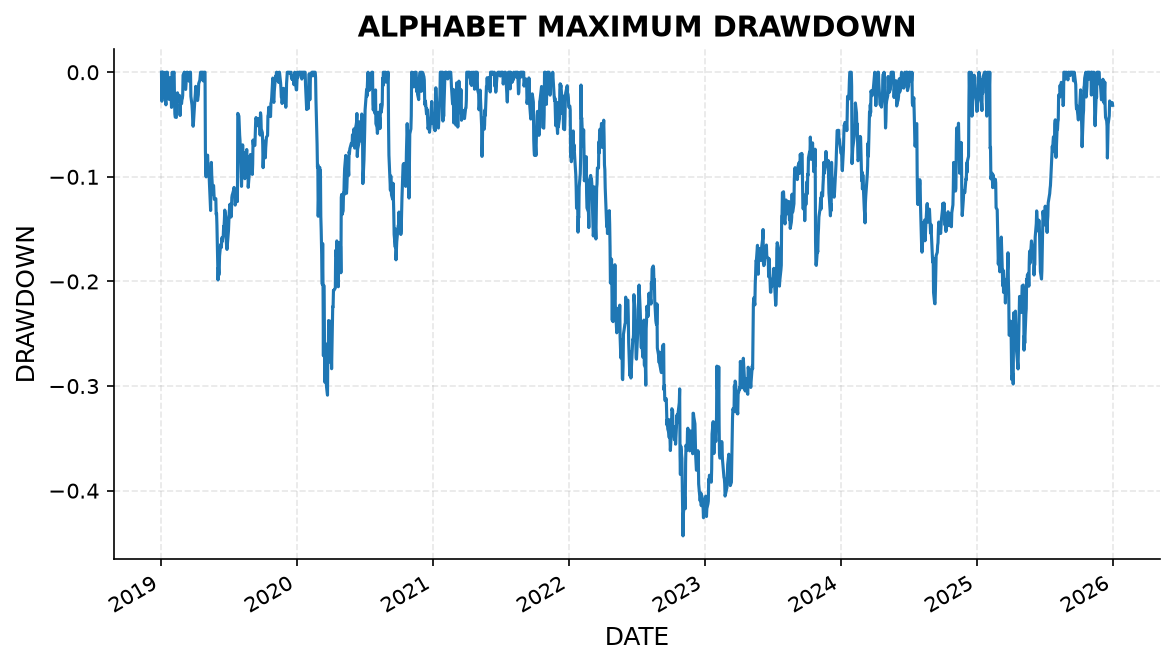

In [137]:
DRAWDOWN['GOOGL'].plot()
plt.title('ALPHABET MAXIMUM DRAWDOWN')
plt.xlabel('DATE')
plt.ylabel('DRAWDOWN')
plt.show()

In [138]:
MAXIMUM_DRAWDOWN

GOOGL   -0.443200
^GSPC   -0.339250
META    -0.767361
NFLX    -0.759473
AMZN    -0.561453
dtype: float64

In [139]:
MDD_DATE

Timestamp('2022-11-03 00:00:00')

# CORRELATION MATRIX AND VISUALIZATION 

In [140]:
Correlation = DSR.corr()

In [141]:
Correlation

,GOOGL,^GSPC,META,NFLX,AMZN
GOOGL,1.000000,0.721033,0.608215,0.420598,0.629344
^GSPC,0.721033,1.000000,0.629087,0.479434,0.660976
META,0.608215,0.629087,1.000000,0.474758,0.616303
NFLX,0.420598,0.479434,0.474758,1.000000,0.519204
AMZN,0.629344,0.660976,0.616303,0.519204,1.000000


In [142]:
Covariance = DSR.cov()*252

In [143]:
Covariance

,GOOGL,^GSPC,META,NFLX,AMZN
GOOGL,0.098394,0.045094,0.079931,0.056217,0.067441
^GSPC,0.045094,0.039753,0.052549,0.040731,0.045021
META,0.079931,0.052549,0.175526,0.084754,0.088209
NFLX,0.056217,0.040731,0.084754,0.181566,0.075579
AMZN,0.067441,0.045021,0.088209,0.075579,0.116707


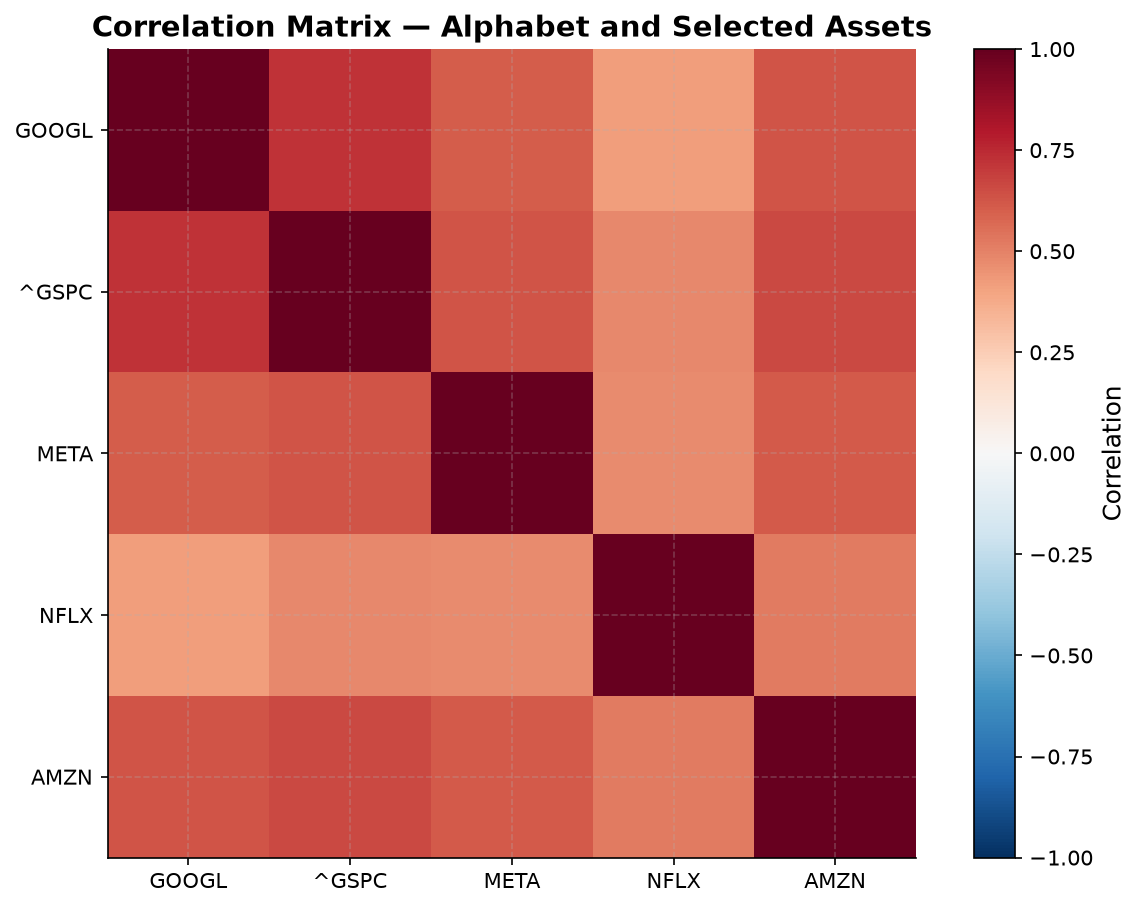

In [144]:
plt.figure(figsize=(10, 7))
plt.imshow(Correlation, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(Correlation)), Correlation.columns)
plt.yticks(range(len(Correlation)), Correlation.columns)
plt.title("Correlation Matrix — Alphabet and Selected Assets")
plt.show()

# CALCULATING CAPM AND SYSTEMATIC RISK

In [145]:
RFR = 0.0464

In [146]:
ERP = ANN_RETURNS['^GSPC'] - RFR

In [147]:
BETA_GOOGL = Covariance.iloc[0,1]/VARIANCE['^GSPC']

In [148]:
BETA_ALL = Covariance['^GSPC']/VARIANCE['^GSPC']

In [149]:
CAPM_GOOGL= RFR + BETA_GOOGL*ERP

In [150]:
ACTUAL_HISTORICAL_RETURN = (ALL['GOOGL'].iloc[-1]/ALL['GOOGL'].iloc[0]-1)

In [151]:
SHARPE_GOOGL = (ANN_RETURNS['GOOGL']-RFR)/ANN_VOL['GOOGL']

In [152]:
CAPM_ALL = RFR + BETA_ALL*ERP

In [153]:
ACTUAL_HISTORICAL_RETURN_ALL = (ALL.iloc[-1]/ALL.iloc[0] -1)

In [154]:
SHARPE_ALL = (ANN_RETURNS -RFR)/ANN_VOL

In [155]:
ALPHA_ALL = ANN_RETURNS - CAPM_ALL

In [156]:
CAPM_SUMMARY = pd.DataFrame({'Annualized Return': ANN_RETURNS,
                             'Beta' : BETA_ALL,
                             'CAPM Required Return': CAPM_ALL,
                             'Sharpe Ratio': SHARPE_ALL,
                             'Alpha': ALPHA_ALL,})

In [157]:
CAPM_SUMMARY

,Annualized Return,Beta,CAPM Required Return,Sharpe Ratio,Alpha
GOOGL,0.305510,1.134377,0.179480,0.826035,1.260299e-01
^GSPC,0.163715,1.000000,0.163715,0.588398,-1.942890e-16
META,0.316296,1.321901,0.201479,0.644207,1.148170e-01
NFLX,0.273148,1.024619,0.166603,0.532141,1.065446e-01
AMZN,0.215661,1.132536,0.179264,0.495460,3.639788e-02


# 2026 PERFORMANCE REVIEW 

In [158]:
YTD_ACTUAL_RETURN = (ALL2026.iloc[-1]/ALL2026.iloc[0]-1)

In [159]:
DR = ALL2026.pct_change()
YTD_VOL = DR.std()*np.sqrt(252)

In [160]:
MAX_2026 = ALL2026.cummax()

In [161]:
DRAWDOWN_2026 = (ALL2026 - MAX_2026)/MAX_2026

In [162]:
MAX_DRAWDOWN_2026 = DRAWDOWN_2026.min()

In [163]:
ANN_2026_RETURN = DR.mean()*252

In [164]:
SHARPE_2026 = (ANN_2026_RETURN - RFR)/YTD_VOL

In [165]:
SUMMARY_2026 = pd.DataFrame({'Actual Return': YTD_ACTUAL_RETURN,
                             'Actual Volatility': YTD_VOL,
                             'Maximum Drawdown': MAX_DRAWDOWN_2026,
                             'Sharpe Ratio': SHARPE_2026})

In [166]:
ACTUAL_2026 = pd.DataFrame({'Metric': ['Return', 'Volatility', 'Sharpe Ratio', 'Maximum Drawdown'],
                             'Alphabet': [YTD_ACTUAL_RETURN['GOOGL'], YTD_VOL['GOOGL'], SHARPE_2026['GOOGL'],
                                          MAX_DRAWDOWN_2026['GOOGL']]})

In [167]:
SUMMARY_2026

,Actual Return,Actual Volatility,Maximum Drawdown,Sharpe Ratio
GOOGL,0.086610,0.333783,-0.210472,0.412655
^GSPC,0.119156,0.135668,-0.090975,1.016601
META,-0.112609,0.430042,-0.287332,-0.326860
NFLX,-0.104737,0.373429,-0.372855,-0.401051
AMZN,0.149139,0.362336,-0.196419,0.644641


In [168]:
Normalized1 = ALL2026[['GOOGL','^GSPC']]/ALL2026[['GOOGL','^GSPC']].iloc[0] * 100

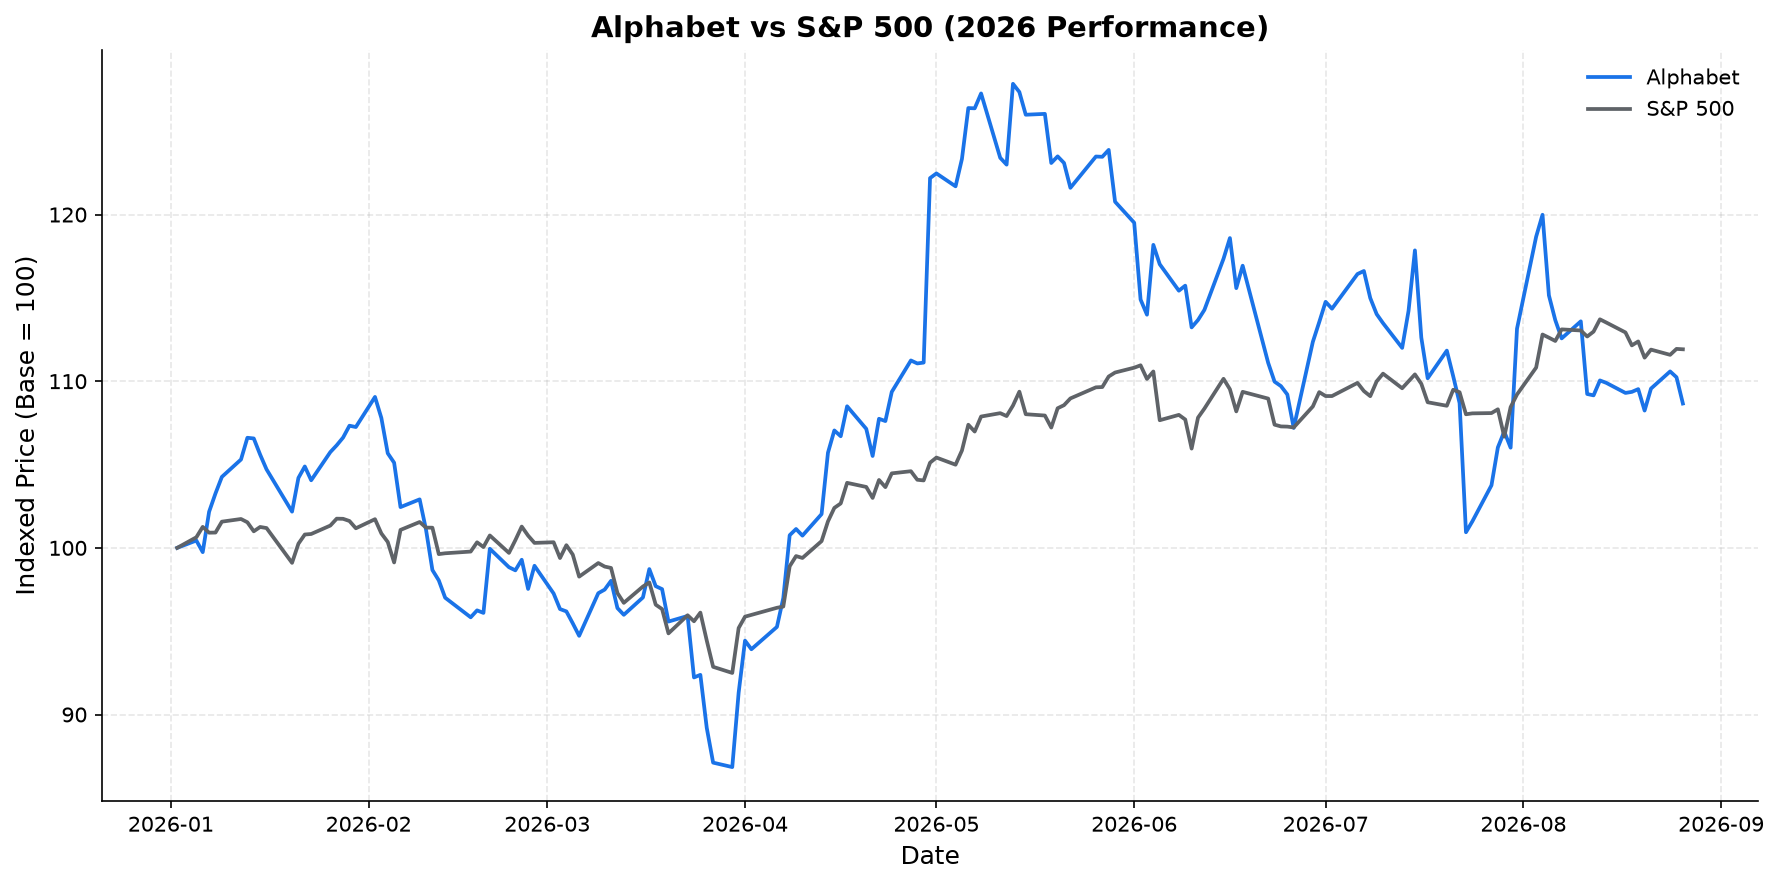

In [171]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(Normalized1.index, Normalized1['GOOGL'],
        label="Alphabet",
        color=COLORS["Alphabet"],
        linewidth=1.8)

ax.plot(Normalized1.index, Normalized1['^GSPC'],
        label="S&P 500",
        color=COLORS["S&P500"],
        linewidth=1.8)

ax.set_title("Alphabet vs S&P 500 (2026 Performance)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Price (Base = 100)")
ax.legend()

fig.tight_layout()

fig.savefig("alphabet_vs_sp500_2026.png", dpi=300, bbox_inches="tight")

plt.show()

In [169]:
Normalized2 = ALL2026[['GOOGL','AMZN','META']]/ALL2026[['GOOGL','AMZN','META']].iloc[0] * 100

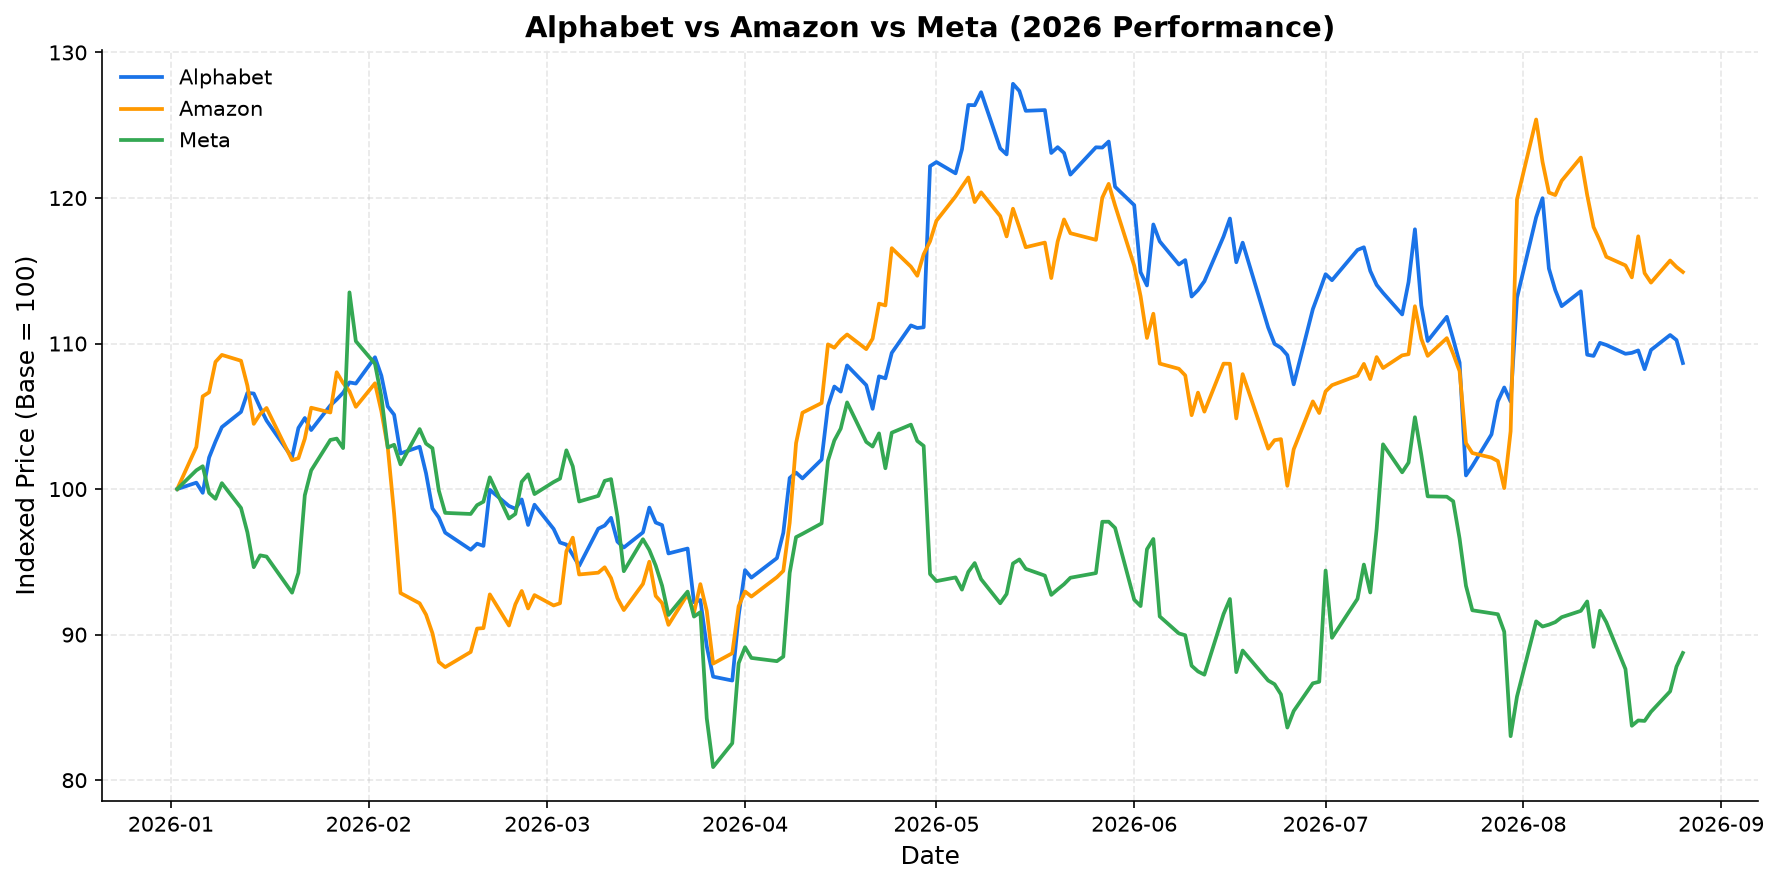

In [172]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(Normalized2.index, Normalized2['GOOGL'],
        label="Alphabet",
        color=COLORS["Alphabet"],
        linewidth=1.8)

ax.plot(Normalized2.index, Normalized2['AMZN'],
        label="Amazon",
        color=COLORS["Amazon"],
        linewidth=1.8)

ax.plot(Normalized2.index, Normalized2['META'],
        label="Meta",
        color=COLORS["Meta"],
        linewidth=1.8)

ax.set_title("Alphabet vs Amazon vs Meta (2026 Performance)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Price (Base = 100)")
ax.legend()

fig.tight_layout()

fig.savefig("alphabet_amazon_meta_2026.png", dpi=300, bbox_inches="tight")

plt.show()

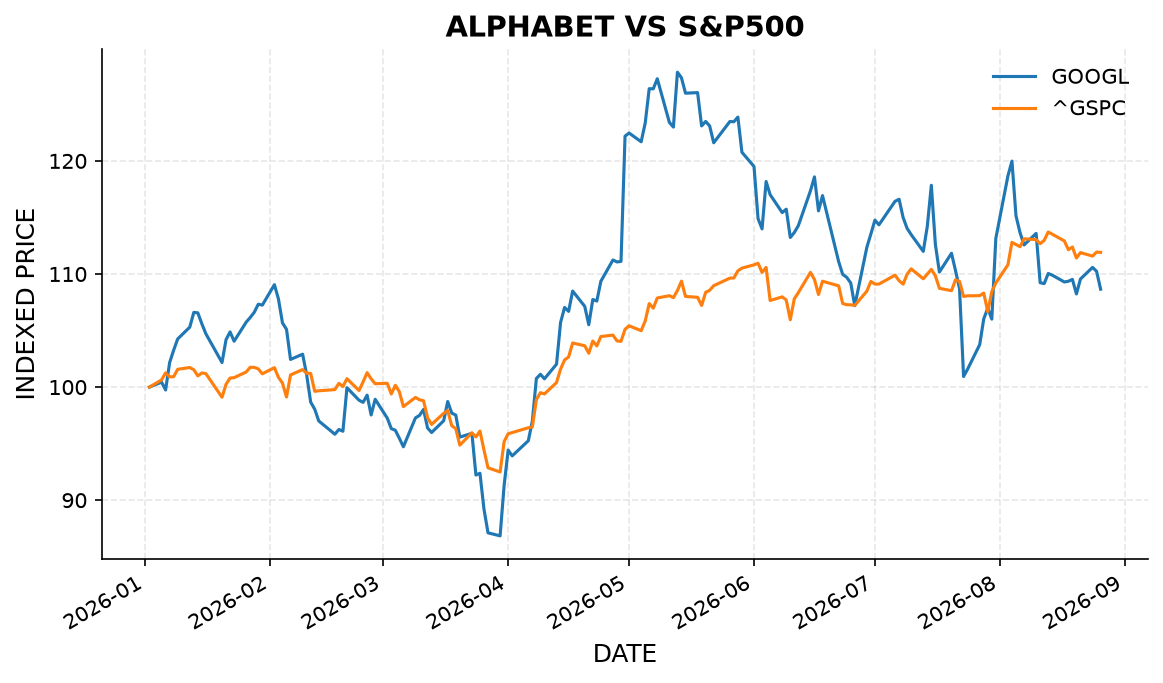

In [170]:
Normalized1.plot()
plt.title ('ALPHABET VS S&P500')
plt.xlabel ('DATE')
plt.ylabel ('INDEXED PRICE')
plt.show()

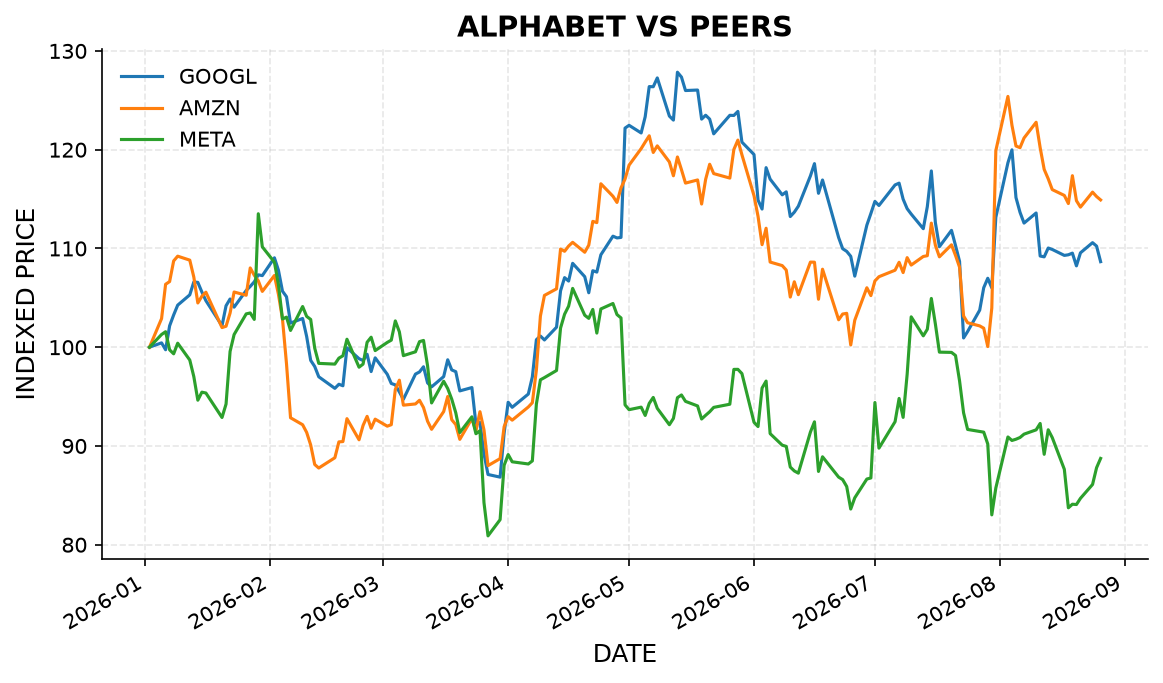

In [174]:
Normalized2.plot()
plt.title ('ALPHABET VS PEERS')
plt.xlabel ('DATE')
plt.ylabel ('INDEXED PRICE')
plt.show()

In [175]:
ACTUAL_2026

,Metric,Alphabet
0,Return,0.086610
1,Volatility,0.333783
2,Sharpe Ratio,0.412655
3,Maximum Drawdown,-0.210472


# Monte Carlo Simulation 

In [176]:
Data = yf.download('GOOGL', '2019-1-1')['Close']

[*********************100%***********************]  1 of 1 completed


In [177]:
LROR = np.log(Data).diff(1)

In [178]:
MEAN = LROR.mean()

In [179]:
VOL = LROR.std()

In [180]:
Last_Price = Data.iloc[-1].item()

In [181]:
Last_Price

342.0

In [182]:
Trading_Days = 252

In [183]:
Simulations = 10000

In [184]:
Random_Returns = np.random.normal(MEAN, VOL,(Trading_Days, Simulations))

In [185]:
Simulated_Prices = Last_Price * np.exp(np.cumsum(Random_Returns, axis =0))

In [195]:
Simulated_Prices.shape

(252, 10000)

In [186]:
Final_Price = Simulated_Prices[-1]

In [187]:
Mean_Final_Price = np.mean(Final_Price)
Median_Final_Price = np.median(Final_Price)
Percentile_5 = np.percentile(Final_Price, 5)
Percentile_25 = np.percentile(Final_Price, 25)
Percentile_75 = np.percentile(Final_Price, 75)
Percentile_95 = np.percentile(Final_Price, 95)

In [188]:
Percentile_95

np.float64(727.3937145266744)

In [189]:
Probability_profit = np.mean(Final_Price>Last_Price)

In [190]:
Probability_profit 

np.float64(0.7795)

In [191]:
Probability_loss = np.mean(Final_Price<Last_Price)

In [192]:
Probability_loss

np.float64(0.2205)

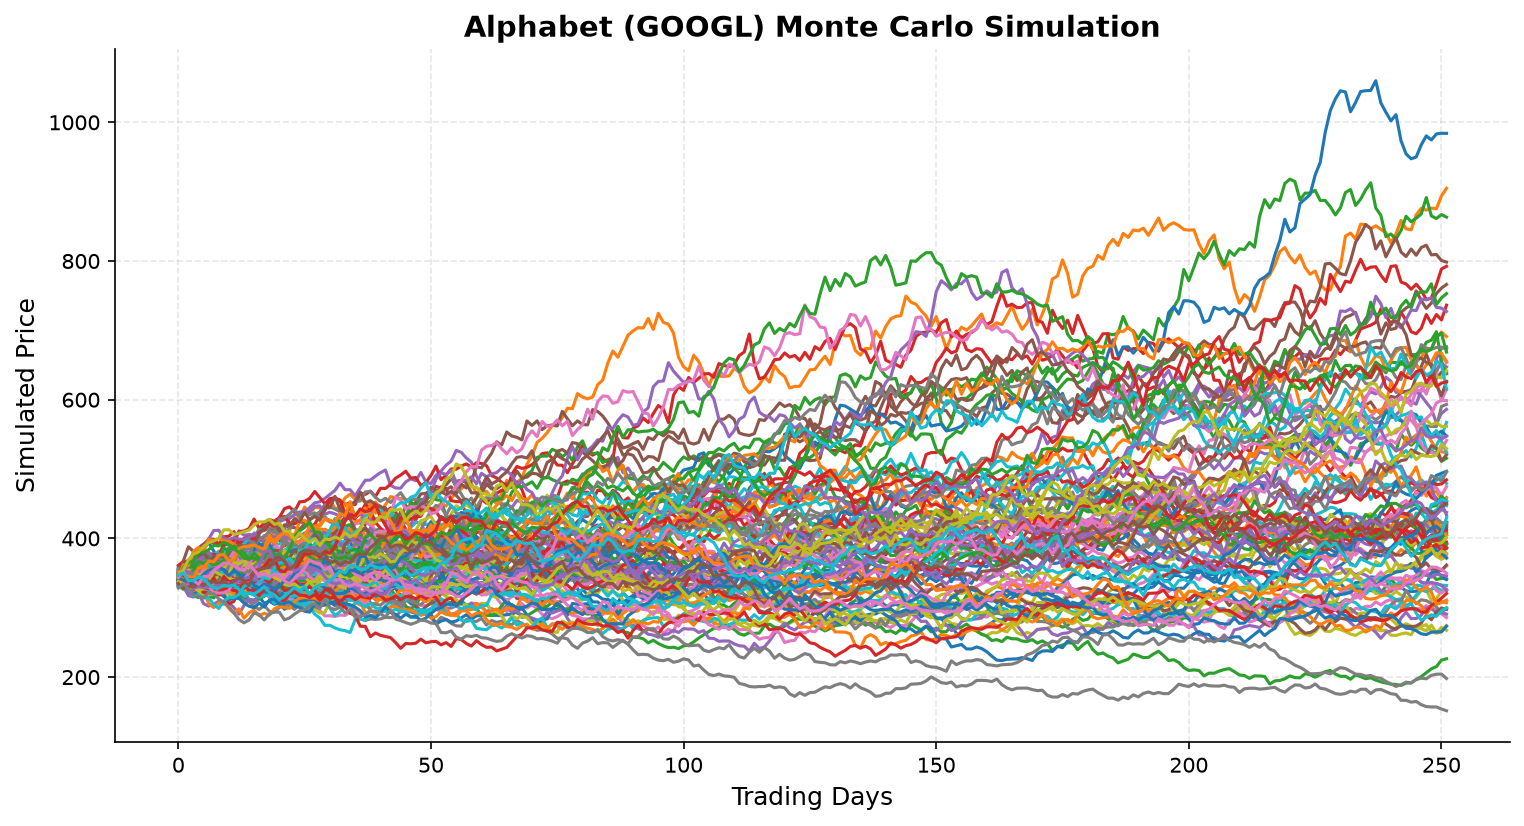

In [193]:
plt.figure(figsize=(12, 6))
plt.plot(Simulated_Prices[:, :100])
plt.title("Alphabet (GOOGL) Monte Carlo Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Simulated Price")
plt.show()

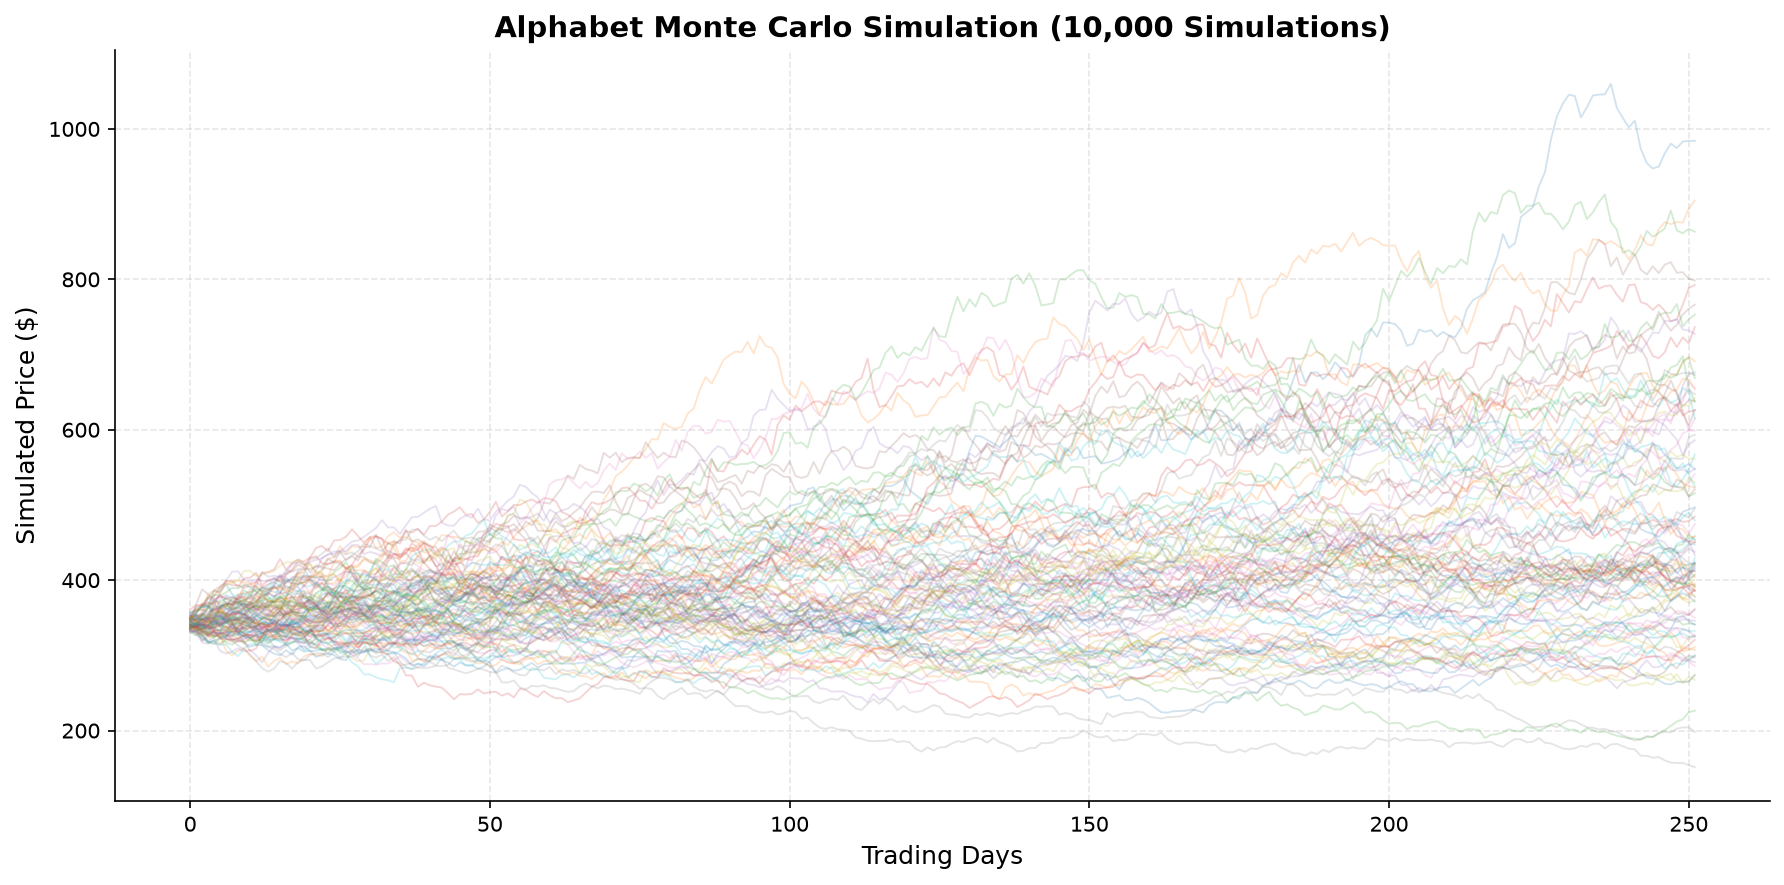

In [198]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    Simulated_Prices[:, :100],
    alpha=0.20,
    linewidth=0.9
)

ax.set_title("Alphabet Monte Carlo Simulation (10,000 Simulations)")
ax.set_xlabel("Trading Days")
ax.set_ylabel("Simulated Price ($)")

fig.tight_layout()

fig.savefig(
    "alphabet_monte_carlo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
MONTE_CARLO_SUMMARY = pd.DataFrame({'Current Price': Last_Price,
                        'Mean Simulated Price': Mean_Final_Price,
                        'Median Simulated Price': Median_Final_Price,
                        '5th Percentile': Percentile_5,
                        '25th Percentile': Percentile_25,
                        '75th Percentile': Percentile_75,
                        '95th Percentile': Percentile_95, 
                        'Probability of Profit': Probability_profit,
                        'Probability of loss': Probability_loss}, index =[0])

In [100]:
MONTE_CARLO_SUMMARY

,Current Price,Mean Simulated Price,Median Simulated Price,5th Percentile,25th Percentile,75th Percentile,95th Percentile,Probability of Profit,Probability of loss
0,346.959991,464.300325,443.124164,262.067247,359.330876,547.275038,739.225385,0.7844,0.2156


# PORTFOLIO APPLICATION & OPTIMIZATION 

In [101]:
Tickers = ('GOOGL','AMZN','META','^GSPC')
PORTFOLIO = pd.DataFrame()
for t in Tickers: 
    PORTFOLIO[t] = yf.download(t, '2019-1-1','2026-1-1')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [102]:
SROR = PORTFOLIO.pct_change()

In [103]:
AVG_SROR = SROR.mean()

In [104]:
ANN_SROR = AVG_SROR*252

In [105]:
ANN_PCOV = SROR.cov()*252

In [106]:
WEIGHT = np.array([0.25,0.25,0.25,0.25])

In [107]:
PORT_EXPR1 = np.dot(WEIGHT, ANN_SROR)

In [108]:
PORT_EXPV1 = np.dot(WEIGHT.T, np.dot(ANN_PCOV, WEIGHT))**0.5

In [109]:
PORT_SHARPE1 = (PORT_EXPR1 - RFR)/PORT_EXPV1

In [110]:
HISTORICAL_PORTFOLIO_SUMMARY = pd.DataFrame({'Portfolio Expected Return': PORT_EXPR1,
                                        'Portfolio Expected Volatility': PORT_EXPV1,
                                        'Portfolio Sharpe Ratio': PORT_SHARPE1},index =[0])

In [111]:
HISTORICAL_PORTFOLIO_SUMMARY

,Portfolio Expected Return,Portfolio Expected Volatility,Portfolio Sharpe Ratio
0,0.250295,0.272359,0.748627


In [112]:
from scipy.optimize import minimize

In [113]:
Bounds = ((0,1),(0,1),(0,1),(0,1))

In [114]:
Initial_Weight = np.array([0.25,0.25,0.25,0.25])

In [115]:
Constraint = ({'type':'eq', 'fun': lambda weight:np.sum(weight)-1})

In [116]:
def PORT_EXPR1(weight):
    return np.dot(weight, ANN_SROR)

In [117]:
def PORT_EXPV1(weight):
    return (np.dot(weight.T, np.dot(ANN_PCOV, weight)))**0.5

In [118]:
def PORT_SHARPE1(weight):
    return (PORT_EXPR1(weight) - RFR)/PORT_EXPV1(weight)

# MINIMUM RISK OPTIMIZATION 

In [119]:
MIN_VOL = minimize(PORT_EXPV1, Initial_Weight, method = 'SLSQP', bounds = Bounds, constraints = Constraint)

In [120]:
MIN_VOL_WEIGHT = np.round(MIN_VOL.x *100,2)

In [121]:
MIN_VOL_RETURN = PORT_EXPR1(MIN_VOL_WEIGHT)

In [122]:
MIN_VOL_VALUE = PORT_EXPV1(MIN_VOL_WEIGHT)

In [123]:
MIN_VOL_SHARPE = PORT_SHARPE1(MIN_VOL_WEIGHT)

# MAXIMUM RETURN OPTIMIZATION 

In [124]:
def Negative_Return(weight):
    return -PORT_EXPR1(weight)

In [125]:
MAX_RETURN = minimize(Negative_Return, Initial_Weight, method ='SLSQP', bounds = Bounds, constraints = Constraint)

In [126]:
MAX_RETURN_WEIGHT = np.round(MAX_RETURN.x *100,2)

In [127]:
MAX_RETURN_VALUE = PORT_EXPR1(MAX_RETURN_WEIGHT)

In [128]:
MAX_RETURN_VOL = PORT_EXPV1(MAX_RETURN_WEIGHT)

In [129]:
MAX_RETURN_SHARPE = PORT_SHARPE1(MAX_RETURN_WEIGHT)

# MAXIMUM SHARPE OPTIMIZATION 

In [130]:
def Negative_Sharpe(weight):
    return - PORT_SHARPE1(weight)

In [131]:
MAX_SHARPE = minimize(Negative_Sharpe, Initial_Weight, method = 'SLSQP', bounds = Bounds, constraints = Constraint)

In [132]:
MAX_SHARPE_WEIGHT = np.round(MAX_SHARPE.x *100,2)

In [133]:
MAX_SHARPE_RETURN = PORT_EXPR1(MAX_SHARPE_WEIGHT)

In [134]:
MAX_SHARPE_VOL = PORT_EXPV1(MAX_SHARPE_WEIGHT)

In [135]:
MAX_SHARPE_VALUE = PORT_SHARPE1(MAX_SHARPE_WEIGHT) 

In [136]:
OPTIMIZATION_WEIGHT_SUMMARY = pd.DataFrame({
    "GOOGL": [MIN_VOL_WEIGHT[0], MAX_RETURN_WEIGHT[0], MAX_SHARPE_WEIGHT[0]],
    
    "META": [MIN_VOL_WEIGHT[1], MAX_RETURN_WEIGHT[1], MAX_SHARPE_WEIGHT[1]],
    
    "AMZN": [MIN_VOL_WEIGHT[2], MAX_RETURN_WEIGHT[2], MAX_SHARPE_WEIGHT[2] ],
    
    "^GSPC": [MIN_VOL_WEIGHT[3], MAX_RETURN_WEIGHT[3], MAX_SHARPE_WEIGHT[3]]},
index=[
    "Minimum Volatility",
    "Maximum Return",
    "Maximum Sharpe"
])

In [137]:
OPTIMIZATION_WEIGHT_SUMMARY

,GOOGL,META,AMZN,^GSPC
Minimum Volatility,0.00,0.0,0.00,100.0
Maximum Return,0.00,0.0,100.00,0.0
Maximum Sharpe,80.35,0.0,19.65,0.0


In [138]:
Ticker = ('GOOGL','AMZN','META','^GSPC')
PORT = pd.DataFrame()
for t in Ticker: 
    PORT[t] = yf.download(t, '2026-1-1')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [144]:
weight1 = np.array([0,0,0,1])

In [145]:
weight2 = np.array([0,0,1,0])

In [146]:
weight3 = np.array([0.8034,0,0.1966,0])

In [147]:
weight4 = np.array([0.25,0.25,0.25,0.25])

In [148]:
Actual_YTDR = PORT.iloc[-1]/PORT.iloc[0]-1

In [149]:
ROR = PORT.pct_change()
COV = ROR.cov()
ANN_YCOV= COV*252

EQUAL WEIGHT PORTFOLIO

In [150]:
RETURN0 = np.dot(weight4, Actual_YTDR)

In [151]:
VOL0 = np.dot(weight4.T, np.dot(ANN_YCOV, weight4))**0.5

In [152]:
SHARPE0 = (RETURN0 - RFR)/VOL0

MININMUM VOLATILITY PORTFOLIO

In [153]:
RETURN1 = np.dot(weight1, Actual_YTDR)

In [154]:
VOL1 = np.dot(weight1.T, np.dot(ANN_YCOV, weight1))**0.5

In [155]:
SHARPE1 = (RETURN1 - RFR)/VOL1

MAXIMUM RETURN PORTFOLIO

In [156]:
RETURN2 = np.dot(weight2, Actual_YTDR)

In [157]:
VOL2 = np.dot(weight2.T, np.dot(ANN_YCOV, weight2))**0.5

In [158]:
SHARPE2 = (RETURN2 - RFR)/VOL2

MAXIMUM SHARPE PORTFOLIO

In [159]:
RETURN3 = np.dot(weight3, Actual_YTDR)

In [160]:
RETURN3

np.float64(0.058260155189412424)

In [161]:
VOL3 = np.dot(weight3.T, np.dot(ANN_YCOV, weight3))**0.5

In [162]:
VOL3

np.float64(0.30943671922476185)

In [163]:
SHARPE3 = (RETURN3 - RFR)/VOL3

In [164]:
ACTUAL_PORTFOLIO_SUMMARY = pd.DataFrame({
    'Portfolio': ['Equal Weight', 'Minimum Risk', 'Maximum Return', 'Maximum Sharpe'],
    'Alphabet': [WEIGHT[0], MIN_VOL_WEIGHT[0], MAX_RETURN_WEIGHT[0], MAX_SHARPE_WEIGHT[0]],
    'META': [WEIGHT[1], MIN_VOL_WEIGHT[1], MAX_RETURN_WEIGHT[1], MAX_SHARPE_WEIGHT[1]],
    'AMAZON': [WEIGHT[2], MIN_VOL_WEIGHT[2], MAX_RETURN_WEIGHT[2], MAX_SHARPE_WEIGHT[2]],
    'S&P500': [WEIGHT[3], MIN_VOL_WEIGHT[3], MAX_RETURN_WEIGHT[3], MAX_SHARPE_WEIGHT[3]],
    'YTD RETURN' : [RETURN0, RETURN1, RETURN2, RETURN3],
    'YTD VOLATILITY':[VOL0, VOL1, VOL2, VOL3],
    'YTD SHARPE': [SHARPE0, SHARPE1, SHARPE2, SHARPE3]
})

In [165]:
ACTUAL_PORTFOLIO_SUMMARY

,Portfolio,Alphabet,META,AMAZON,S&P500,YTD RETURN,YTD VOLATILITY,YTD SHARPE
0,Equal Weight,0.25,0.25,0.25,0.25,0.063087,0.249556,0.066868
1,Minimum Risk,0.00,0.00,0.00,100.00,0.119387,0.136086,0.536326
2,Maximum Return,0.00,0.00,100.00,0.00,-0.121989,0.431159,-0.390551
3,Maximum Sharpe,80.35,0.00,19.65,0.00,0.058260,0.309437,0.038328


# Working on the financial position of Alphabet 

In [168]:
import pandas as pd

In [169]:
import numpy as np

In [170]:
Alphabet_Financials = pd.DataFrame({

    'Year': [
        2019, 2020, 2021, 2022, 2023, 2024, 2025
    ],

    # USD millions
    'Revenue': [
        161857,
        182527,
        257637,
        282836,
        307394,
        350018,
        402836
    ],

    'Operating_Income': [
        34231,
        41224,
        78714,
        74842,
        84293,
        112390,
        129039
    ],

    'Net_Income': [
        34343,
        40269,
        76033,
        59972,
        73795,
        100118,
        132170
    ],

    'Operating_Cash_Flow': [
        54520,
        65124,
        91652,
        91495,
        101746,
        125299,
        164713
    ],

    'Capital_Expenditure': [
        23548,
        22281,
        24640,
        31485,
        32251,
        52535,
        91447
    ],

    'Liquidity': [
        119675,
        136694,
        139649,
        113763,
        110916,
        95657,
        126843
    ]
})

Alphabet_Financials

,Year,Revenue,Operating_Income,Net_Income,Operating_Cash_Flow,Capital_Expenditure,Liquidity
0,2019,161857,34231,34343,54520,23548,119675
1,2020,182527,41224,40269,65124,22281,136694
2,2021,257637,78714,76033,91652,24640,139649
3,2022,282836,74842,59972,91495,31485,113763
4,2023,307394,84293,73795,101746,32251,110916
5,2024,350018,112390,100118,125299,52535,95657
6,2025,402836,129039,132170,164713,91447,126843


In [171]:
Alphabet_Financials['Free_Cash_Flow'] = (
    Alphabet_Financials['Operating_Cash_Flow']
    -
    Alphabet_Financials['Capital_Expenditure']
)

Alphabet_Financials

,Year,Revenue,Operating_Income,Net_Income,Operating_Cash_Flow,Capital_Expenditure,Liquidity,Free_Cash_Flow
0,2019,161857,34231,34343,54520,23548,119675,30972
1,2020,182527,41224,40269,65124,22281,136694,42843
2,2021,257637,78714,76033,91652,24640,139649,67012
3,2022,282836,74842,59972,91495,31485,113763,60010
4,2023,307394,84293,73795,101746,32251,110916,69495
5,2024,350018,112390,100118,125299,52535,95657,72764
6,2025,402836,129039,132170,164713,91447,126843,73266


In [172]:
Alphabet_Financials['Revenue_Growth'] = Alphabet_Financials['Revenue'].pct_change()*100

In [173]:
Alphabet_Financials['Operating_Margin'] = (Alphabet_Financials['Operating_Income']/Alphabet_Financials['Revenue'])*100

In [174]:
Alphabet_Financials['Net_Margin'] = (Alphabet_Financials['Net_Income']/Alphabet_Financials['Revenue'])*100

In [175]:
Alphabet_Financials['FCF_Growth'] = Alphabet_Financials['Free_Cash_Flow'].pct_change()*100

In [176]:
Alphabet_Financials

,Year,Revenue,Operating_Income,Net_Income,Operating_Cash_Flow,Capital_Expenditure,Liquidity,Free_Cash_Flow,Revenue_Growth,Operating_Margin,Net_Margin,FCF_Growth
0,2019,161857,34231,34343,54520,23548,119675,30972,NaN,21.148915,21.218112,NaN
1,2020,182527,41224,40269,65124,22281,136694,42843,12.770532,22.585152,22.061942,38.328167
2,2021,257637,78714,76033,91652,24640,139649,67012,41.150076,30.552289,29.511677,56.412950
3,2022,282836,74842,59972,91495,31485,113763,60010,9.780816,26.461271,21.203807,-10.448875
4,2023,307394,84293,73795,101746,32251,110916,69495,8.682770,27.421810,24.006649,15.805699
5,2024,350018,112390,100118,125299,52535,95657,72764,13.866243,32.109777,28.603672,4.703936
6,2025,402836,129039,132170,164713,91447,126843,73266,15.090081,32.032639,32.809878,0.689902


In [177]:
Alphabet_2026 = pd.DataFrame({

    'Period': [
        '6M 2025',
        '6M 2026'
    ],

    'Revenue': [
        186662,
        229692
    ],

    'Operating_Income': [
        61877,
        80466
    ],

    'Operating_Cash_Flow': [
        63897,
        84859
    ],

    'Capital_Expenditure': [
        39643,
        80598
    ]
})

In [178]:
Alphabet_2026

,Period,Revenue,Operating_Income,Operating_Cash_Flow,Capital_Expenditure
0,6M 2025,186662,61877,63897,39643
1,6M 2026,229692,80466,84859,80598


In [179]:
Alphabet_2026['Free_Cash_Flow'] = (
    Alphabet_2026['Operating_Cash_Flow']
    -
    Alphabet_2026['Capital_Expenditure']
)

In [180]:
Alphabet_2026

,Period,Revenue,Operating_Income,Operating_Cash_Flow,Capital_Expenditure,Free_Cash_Flow
0,6M 2025,186662,61877,63897,39643,24254
1,6M 2026,229692,80466,84859,80598,4261


In [181]:
Alphabet_2026['Revenue_Growth'] = Alphabet_2026['Revenue'].pct_change()*100

In [182]:
Alphabet_2026['Operating_Margin'] = (Alphabet_2026['Operating_Income']/Alphabet_2026['Revenue'])*100

In [183]:
Alphabet_2026['Operating_Income_Growth'] = Alphabet_2026['Operating_Income'].pct_change()*100

In [184]:
Alphabet_2026['OCF_Growth'] = Alphabet_2026['Operating_Cash_Flow'].pct_change()*100

In [185]:
Alphabet_2026['CapEx_Growth'] = Alphabet_2026['Capital_Expenditure'].pct_change()*100

In [186]:
Alphabet_2026['FCF_Growth'] = Alphabet_2026['Free_Cash_Flow'].pct_change()*100

In [187]:
Alphabet_2026

,Period,Revenue,Operating_Income,Operating_Cash_Flow,Capital_Expenditure,Free_Cash_Flow,Revenue_Growth,Operating_Margin,Operating_Income_Growth,OCF_Growth,CapEx_Growth,FCF_Growth
0,6M 2025,186662,61877,63897,39643,24254,NaN,33.149222,NaN,NaN,NaN,NaN
1,6M 2026,229692,80466,84859,80598,4261,23.052362,35.032130,30.041857,32.805922,103.309538,-82.431764


In [199]:
import mplfinance as mpf

In [208]:
Chart = yf.download('GOOGL', '2025-01-01')
if isinstance(Chart.columns, pd.MultiIndex):
    Chart.columns = Chart.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [209]:
Chart

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,188.445694,191.002347,186.525730,189.659356,20370800
2025-01-03,190.793442,192.206077,188.992849,190.375626,18596200
2025-01-06,195.847046,197.190037,192.842749,192.972063,29563600
2025-01-07,194.474228,199.955592,193.588853,196.085805,26487200
2025-01-08,192.942230,195.270068,191.380396,191.569411,24864800
...,...,...,...,...,...
2026-08-20,340.670013,343.899994,338.570007,343.059998,18570400
2026-08-21,344.820007,346.200012,340.399994,342.579987,20849800
2026-08-24,348.059998,351.600006,342.489990,343.619995,26338200


In [210]:
Chart = Chart[['Open','High','Low','Close','Volume']]

In [211]:
Chart['100SMA']= Chart['Close'].rolling(window=100).mean()

In [212]:
Chart['200SMA'] = Chart['Close'].rolling(window=200).mean()

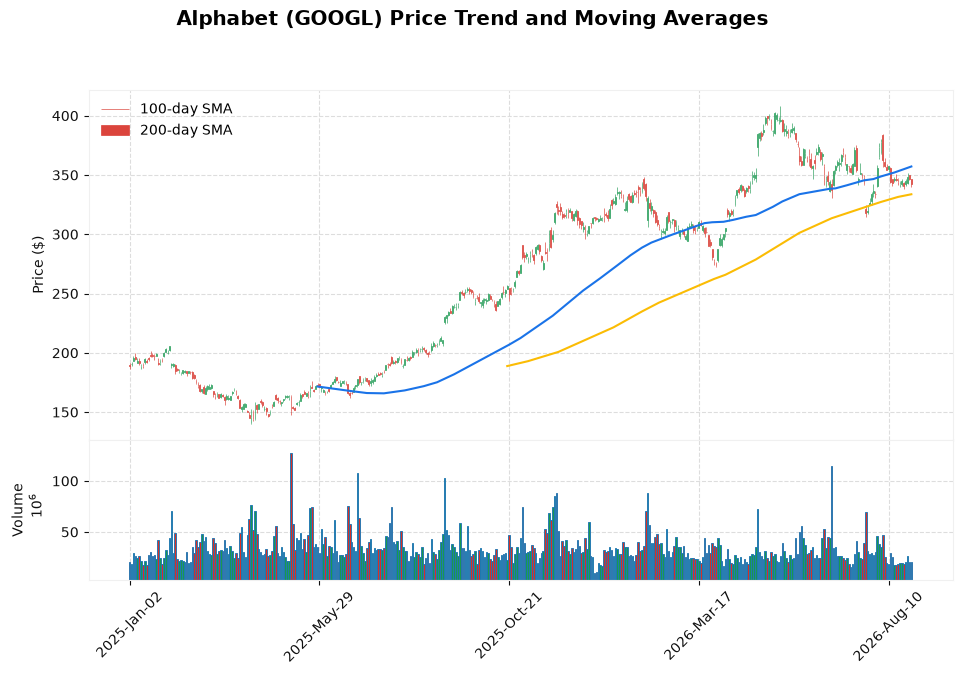

In [215]:
# Custom market colors
mc = mpf.make_marketcolors(
    up="#1a9850",
    down="#d73027",
    edge="inherit",
    wick="inherit",
    volume="inherit"
)

# Custom chart style
style = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    marketcolors=mc,
    gridstyle="--",
    gridcolor="#dddddd",
    facecolor="white",
    figcolor="white",
    y_on_right=False,
    rc={"font.size": 10}
)

# 100-day and 200-day SMA overlays
sma100_plot = mpf.make_addplot(
    Chart["100SMA"],
    color="#1a73e8",
    width=1.5,
    label="100-day SMA"
)

sma200_plot = mpf.make_addplot(
    Chart["200SMA"],
    color="#fbbc04",
    width=1.5,
    label="200-day SMA"
)

# Create chart
fig, axes = mpf.plot(
    Chart,
    type="candle",
    style=style,
    addplot=[sma100_plot, sma200_plot],
    volume=True,
    figsize=(12, 7),
    title="Alphabet (GOOGL) Price Trend and Moving Averages",
    ylabel="Price ($)",
    ylabel_lower="Volume",
    returnfig=True
)

# SMA legend
axes[0].legend(
    ["100-day SMA", "200-day SMA"],
    loc="upper left",
    frameon=False
)

# Save high-resolution version for Word
fig.savefig(
    "alphabet_technical_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [216]:
fig.savefig(
    "alphabet_technical_analysis.png",
    dpi=300,
    bbox_inches="tight"
)